<a href="https://colab.research.google.com/github/ansaganakhat/project-1/blob/main/final_lab_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Қорытынды практикалық жұмыс: Регрессия тапсырмасы

## Бетон қоспасының сығылу беріктігін болжау


## Кіріспе

 Тапсырманың мәні: бетон қоспасының құрамы (цемент, су, ұсақ және ірі толтырғыштар, қоспалар) мен қатаю мерзіміне қарай оның сығылу беріктігін мегапаскальмен (MPa) болжау. Бұл — құрылыс индустриясындағы нақты инженерлік есеп. Бірқатар ұяшықтарда толық код қаңқасы берілмеген — қандай шешім қабылдау керегін өзіңіз таңдайсыз және оны түсініктемелерде негіздейсіз.

## Оқу мақсаттары

Осы зертханалық жұмысты аяқтағаннан кейін сіз:
- Ұзын және орынсыз аталған бағандарды өңдей аласыз;
- Регрессия үшін EDA жүргізіп, белгілер арасындағы сызықты емес байланысты анықтай аласыз;
- Кемінде төрт регрессия алгоритмін салыстыра аласыз;
- MAE, RMSE, R² метрикаларының айырмашылығын түсіндіре аласыз;
- Регуляризация мен ансамбльдердің әсерін тәжірибе жүзінде көрсете аласыз.

## Мазмұны

1. Кітапханаларды импорттау
2. Деректерді жүктеу
3. Барлаушы деректер талдауы (EDA)
4. Деректерді алдын ала өңдеу
5. Оқу және тест жиынтығына бөлу
6. Базалық модельдер
7. Гиперпараметрлерді баптау
8. Соңғы модельді бағалау
9. Қорытынды және талқылау

## 1. Кітапханаларды импорттау

Төмендегі ұяшық негізгі кітапханаларды жүктейді. Егер қосымша кітапхана керек болса, оны да осында қосыңыз.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
sns.set_style('whitegrid')

## 2. Деректерді жүктеу

Concrete Compressive Strength деректер жиынтығы GitHub-тағы ашық репозиторийден жүктеледі. Онда сегіз белгі (әрқайсысы бір кубометрдегі килограмм есебімен) және мақсаттық белгі — MPa бойынша беріктік бар. Бір ескеретін жайт: баған атаулары ұзын, өлшем бірліктері мен арнайы таңбалары бар. Бұл нақты өмірде жиі кездесетін жағдай — сіз оны алдын ала өңдеу қадамдарында тазалауыңыз керек.

In [2]:
URL = 'https://raw.githubusercontent.com/YBI-Foundation/Dataset/main/Concrete%20Compressive%20Strength.csv'
df = pd.read_csv(URL)
print('Пішіні:', df.shape)
df.head()

Пішіні: (1030, 9)


,Cement (kg in a m^3 mixture),Blast Furnace Slag (kg in a m^3 mixture),Fly Ash (kg in a m^3 mixture),Water (kg in a m^3 mixture),Superplasticizer (kg in a m^3 mixture),Coarse Aggregate (kg in a m^3 mixture),Fine Aggregate (kg in a m^3 mixture),Age (day),"Concrete Compressive Strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


### Тапсырма 2.1

Деректің құрылымын өз бетіңізше зерттеп, келесі сұрақтарға жауап беріңіз: неше бақылау бар, барлық белгілер сандық па, мақсаттық белгі қандай мәндер аралығында, оның бөлінуі қалыпты ма әлде қиғаш па. Қорытындыны 3-5 сөйлеммен жазыңыз.

Бақылау саны: 1030
Баған саны: 9

Дерек типтері:


,dtype
Cement (kg in a m^3 mixture),float64
Blast Furnace Slag (kg in a m^3 mixture),float64
Fly Ash (kg in a m^3 mixture),float64
Water (kg in a m^3 mixture),float64
Superplasticizer (kg in a m^3 mixture),float64
Coarse Aggregate (kg in a m^3 mixture),float64
Fine Aggregate (kg in a m^3 mixture),float64
Age (day),int64
"Concrete Compressive Strength(MPa, megapascals)",float64



Жетіспейтін мәндер:


,missing
Cement (kg in a m^3 mixture),0
Blast Furnace Slag (kg in a m^3 mixture),0
Fly Ash (kg in a m^3 mixture),0
Water (kg in a m^3 mixture),0
Superplasticizer (kg in a m^3 mixture),0
Coarse Aggregate (kg in a m^3 mixture),0
Fine Aggregate (kg in a m^3 mixture),0
Age (day),0
"Concrete Compressive Strength(MPa, megapascals)",0



Мақсаттық белгінің сипаттамасы:


,strength
count,1030.000000
mean,35.817836
std,16.705679
min,2.331808
25%,23.707115
50%,34.442774
75%,46.136287
max,82.599225


Strength қиғаштық коэффициенті: 0.417


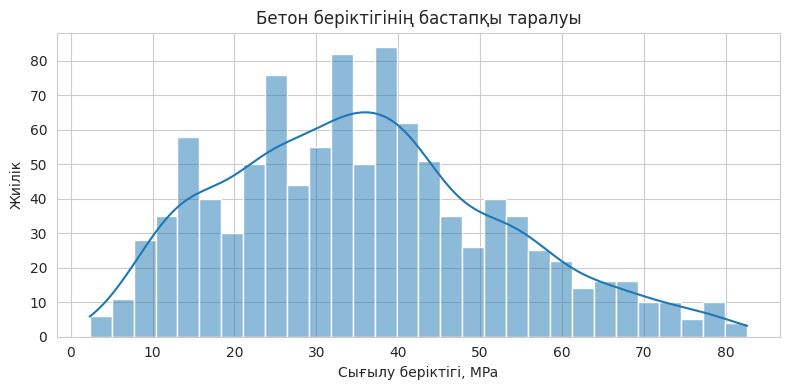

In [3]:
# TODO 2.1: деректі зерттеу

print("Бақылау саны:", df.shape[0])
print("Баған саны:", df.shape[1])

print("\nДерек типтері:")
display(df.dtypes.to_frame("dtype"))

print("\nЖетіспейтін мәндер:")
display(df.isna().sum().to_frame("missing"))

target_original = df.columns[-1]
target_summary = df[target_original].describe()
target_skew = df[target_original].skew()

print("\nМақсаттық белгінің сипаттамасы:")
display(target_summary.to_frame("strength"))
print(f"Strength қиғаштық коэффициенті: {target_skew:.3f}")

plt.figure(figsize=(8, 4))
sns.histplot(df[target_original], bins=30, kde=True)
plt.title("Бетон беріктігінің бастапқы таралуы")
plt.xlabel("Сығылу беріктігі, MPa")
plt.ylabel("Жиілік")
plt.tight_layout()
plt.show()

**2.1 қорытындысы.** Деректер жиынтығында **1030 бақылау және 9 баған** бар: сегіз кіріс белгісі және бір мақсаттық белгі. Барлық баған сандық типте, категориялық және жетіспейтін мәндер жоқ. Беріктік шамамен **2.3–82.6 MPa** аралығында өзгереді. Таралу толық қалыпты емес: оң жақ құйрығы сәл ұзындау, яғни әлсіз оң қиғаштық байқалады.

### Тапсырма 2.2: баған атауларын тазалау

Баған атаулары ұзын және арнайы таңбалары бар (жақшалар, символдар, соңында бос орындар). Кодтауға қолайлы қысқа атауларға ауыстырыңыз (мысалы, `cement`, `slag`, `fly_ash`, `water`, `superplasticizer`, `coarse_agg`, `fine_agg`, `age`, `strength`). Кейінгі бөлімдер осы жаңа атауларды пайдаланады.

In [4]:
# TODO 2.2: бағандарды атын өзгерту
clean_columns = [
    'cement',
    'slag',
    'fly_ash',
    'water',
    'superplasticizer',
    'coarse_agg',
    'fine_agg',
    'age',
    'strength'
]

assert len(df.columns) == len(clean_columns), (
    "Күтілген баған саны сәйкес емес."
)

df.columns = clean_columns

print("Тазаланған баған атаулары:")
print(df.columns.tolist())
display(df.head())


Тазаланған баған атаулары:
['cement', 'slag', 'fly_ash', 'water', 'superplasticizer', 'coarse_agg', 'fine_agg', 'age', 'strength']


,cement,slag,fly_ash,water,superplasticizer,coarse_agg,fine_agg,age,strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


## 3. Барлаушы деректер талдауы (EDA)

Регрессияда EDA-ның екі басты мақсаты бар: белгілер арасындағы байланысты көру және шеткі мәндерді (outliers) анықтау. Екеуін де жасаңыз.

### Тапсырма 3.1

Кемінде **төрт** график жасаңыз. Мысалдар: `strength` мәнінің таралу гистограммасы; `cement` пен `strength` арасындағы scatter plot; `age` мен `strength` арасындағы байланыс (age логарифмдік шкалада қарасаңыз пайдалы болуы мүмкін); барлық белгілердің корреляция матрицасының heatmap-ы. Әр графиктің астына бір-екі сөйлеммен қорытынды жазыңыз.

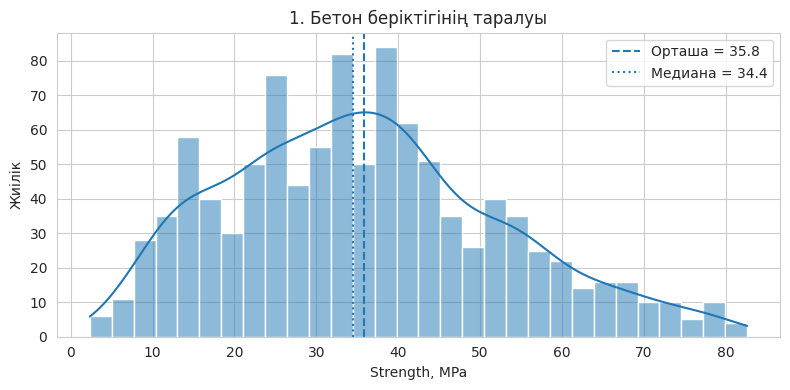

In [5]:
# TODO 3.1: EDA графиктері
# 1-график: strength таралуы
plt.figure(figsize=(8, 4))
sns.histplot(df['strength'], bins=30, kde=True)
plt.axvline(
    df['strength'].mean(),
    linestyle='--',
    label=f"Орташа = {df['strength'].mean():.1f}"
)
plt.axvline(
    df['strength'].median(),
    linestyle=':',
    label=f"Медиана = {df['strength'].median():.1f}"
)
plt.title("1. Бетон беріктігінің таралуы")
plt.xlabel("Strength, MPa")
plt.ylabel("Жиілік")
plt.legend()
plt.tight_layout()
plt.show()


### Тапсырма 3.2: сызықты емес байланыстар

Бетон беріктігі мен қатаю мерзімі (age) арасындағы байланыс сызықты емес — беріктік алдымен тез өседі, содан кейін тұрақталады. Осындай байланысты `LinearRegression` жақсы модельдей ала ма? Егер жоқ болса, шешім жолдары қандай (полиномиальды белгілер, log-трансформация, ағаш моделі)? Пайымдауыңызды жазыңыз.

**Қорытынды:** беріктік мәндерінің негізгі бөлігі орташа диапазонда орналасқан. Таралу сәл оңға қиғаш, сондықтан өте жоғары беріктіктегі үлгілер саны салыстырмалы түрде аз.*Талдауыңызды осы ұяшыққа жазыңыз.*

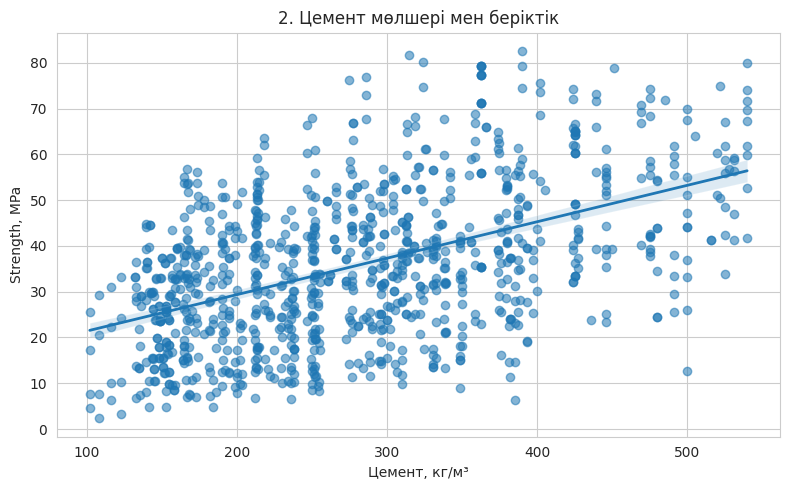

cement-strength Pearson корреляциясы: 0.498


In [6]:
# 2-график: cement және strength
plt.figure(figsize=(8, 5))
sns.regplot(
    data=df,
    x='cement',
    y='strength',
    scatter_kws={'alpha': 0.55},
    line_kws={'linewidth': 2}
)
plt.title("2. Цемент мөлшері мен беріктік")
plt.xlabel("Цемент, кг/м³")
plt.ylabel("Strength, MPa")
plt.tight_layout()
plt.show()

print(
    "cement-strength Pearson корреляциясы:",
    round(df['cement'].corr(df['strength']), 3)
)

**Қорытынды:** цемент мөлшері өскен сайын беріктік жалпы алғанда өседі. Дегенмен шашырау үлкен, себебі беріктікке су, қоспалар және қатаю мерзімі бірге әсер етеді.

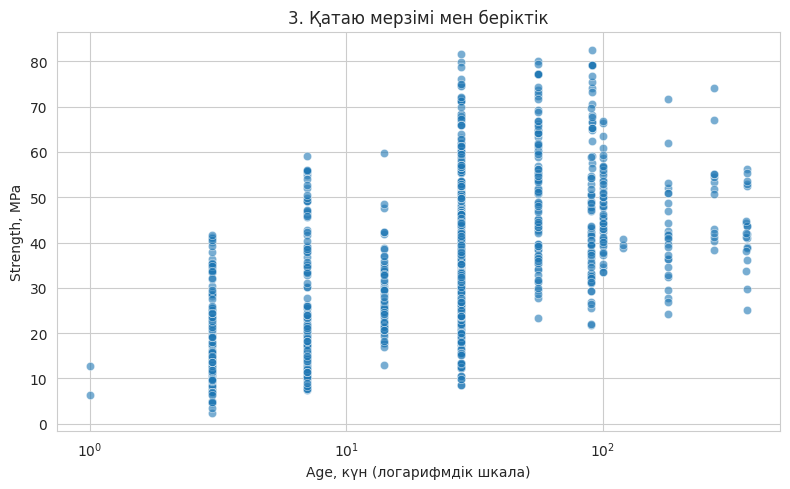

age-strength Pearson корреляциясы: 0.329


In [7]:
# 3-график: age және strength
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x='age',
    y='strength',
    alpha=0.6
)
plt.xscale('log')
plt.title("3. Қатаю мерзімі мен беріктік")
plt.xlabel("Age, күн (логарифмдік шкала)")
plt.ylabel("Strength, MPa")
plt.tight_layout()
plt.show()

print(
    "age-strength Pearson корреляциясы:",
    round(df['age'].corr(df['strength']), 3)
)

**Қорытынды:** беріктік алғашқы күндер мен апталарда жылдам артып, кейін өсім баяулайды. Бұл қатынас сызықты емес және `log(age)` белгісінің пайдалы екенін көрсетеді.

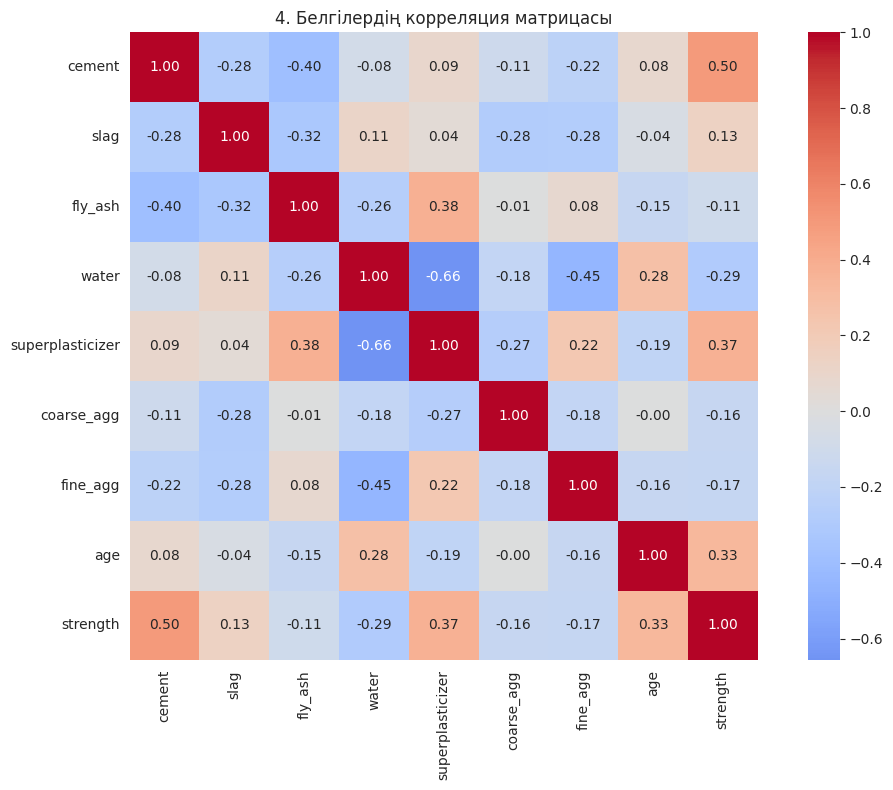

In [8]:
# 4-график: корреляция матрицасы
plt.figure(figsize=(11, 8))
corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True
)
plt.title("4. Белгілердің корреляция матрицасы")
plt.tight_layout()
plt.show()

**Қорытынды:** `cement`, `superplasticizer` және `age` беріктікпен оң байланыс көрсетеді, ал `water` көбіне теріс байланыс береді. Корреляция тек сызықты байланысты өлшейтіндіктен, `age` әсерін толық сипаттамайды.

### Тапсырма 3.3: шеткі мәндер

Кемінде екі белгіде шеткі мәндерді IQR немесе Z-score әдісімен анықтаңыз. Оларды жою керек пе, әлде сол күйінде қалдыру керек пе — өз шешіміңізді жазыңыз. Ескертулер: бетон қоспасының құрамындағы кейбір компоненттер (мысалы, `fly_ash` немесе `slag`) көп жағдайда нөл болуы мүмкін — бұл шеткі мән емес, техникалық норма.

,feature,Q1,Q3,lower_bound,upper_bound,outlier_count,outlier_percent
0,cement,192.38,350.00,-44.06,586.44,0,0.00
1,age,7.00,56.00,-66.50,129.50,59,5.73
2,water,164.90,192.00,124.25,232.65,9,0.87
3,strength,23.71,46.14,-9.94,79.78,4,0.39


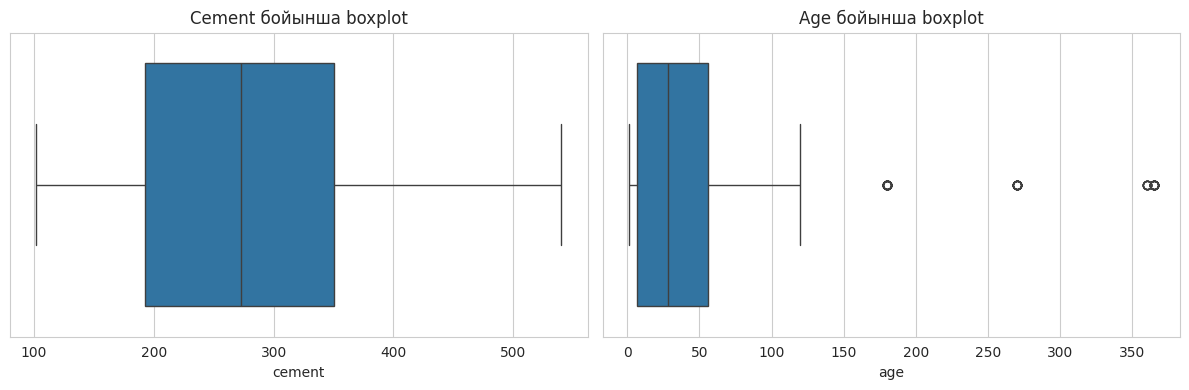

In [9]:
# TODO 3.3: шеткі мәндерді анықтау

def iqr_outlier_summary(data, columns):
    # IQR әдісі арқылы шеткі мәндер санын есептеу
    rows = []

    for col in columns:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        mask = (data[col] < lower) | (data[col] > upper)

        rows.append({
            'feature': col,
            'Q1': q1,
            'Q3': q3,
            'lower_bound': lower,
            'upper_bound': upper,
            'outlier_count': int(mask.sum()),
            'outlier_percent': 100 * mask.mean()
        })

    return pd.DataFrame(rows)


outlier_report = iqr_outlier_summary(
    df,
    ['cement', 'age', 'water', 'strength']
)

display(outlier_report.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df, x='cement', ax=axes[0])
axes[0].set_title("Cement бойынша boxplot")

sns.boxplot(data=df, x='age', ax=axes[1])
axes[1].set_title("Age бойынша boxplot")

plt.tight_layout()
plt.show()

**Шешім:** IQR бойынша кейбір үлкен `age` және қоспа мөлшерлері статистикалық шеткі мән болып көрінеді. Бірақ олар өлшеу қатесі емес: 180–365 күндік сынақтар және жоғары цементті қоспалар инженерлік тұрғыдан мүмкін. Сондықтан оларды жоймаймын. Нөлдік `slag` немесе `fly_ash` та қалыпты технологиялық жағдай, outlier емес.

## 4. Деректерді алдын ала өңдеу

Бұл деректе жетіспейтін мәндер жоқ, категориялық белгілер де жоқ. Бірақ регрессия үшін масштабтау мен белгілер инженериясы маңызды.

### Тапсырма 4.1: белгілер инженериясы

Кемінде **екі жаңа белгі** құрыңыз. Идеялар: су мен цементтің қатынасы (w/c ratio — бетон беріктігіне ең жиі әсер ететін параметрлердің бірі); ірі және ұсақ толтырғыштардың жалпы мөлшері; байланыстырғыш материалдардың жалпы саны (cement + slag + fly_ash); `age` белгісінің логарифмі. Әр белгінің инженерлік мағынасын түсіндіріңіз.

In [10]:
# TODO 4.1: жаңа белгілер
df_model = df.copy()

# Су-цемент қатынасы
df_model['water_cement_ratio'] = (
    df_model['water'] / df_model['cement'].replace(0, np.nan)
)

# Жалпы байланыстырғыш материал
df_model['binder_total'] = (
    df_model['cement']
    + df_model['slag']
    + df_model['fly_ash']
)

# Жалпы толтырғыш
df_model['aggregate_total'] = (
    df_model['coarse_agg']
    + df_model['fine_agg']
)

# Қатаю мерзімінің логарифмі
df_model['log_age'] = np.log1p(df_model['age'])

assert np.isfinite(
    df_model.select_dtypes(include=np.number)
).all().all()

new_features = [
    'water_cement_ratio',
    'binder_total',
    'aggregate_total',
    'log_age'
]

display(df_model[new_features].head())


,water_cement_ratio,binder_total,aggregate_total,log_age
0,0.300000,540.0,1716.0,3.367296
1,0.300000,540.0,1731.0,3.367296
2,0.685714,475.0,1526.0,5.602119
3,0.685714,475.0,1526.0,5.902633
4,0.966767,331.0,1803.9,5.888878


### Тапсырма 4.2: масштабтау

Сызықты модельдер мен KNN масштабқа сезімтал, ал ағаш модельдері сезбейді. `StandardScaler` немесе `MinMaxScaler` таңдап, оны `Pipeline`-ға енгізіңіз. Масштабтаушыны тек оқу жиынтығына `fit` етіңіз — data leakage болмауы үшін.

In [11]:
# TODO 4.2: X және y айнымалыларын дайындау

X = df_model.drop(columns='strength')
y = df_model['strength']

print("X пішіні:", X.shape)
print("y пішіні:", y.shape)
print("Белгілер:", X.columns.tolist())

# StandardScaler кейін Pipeline ішінде қолданылады.
# Осылайша scaler тек train бөлігіне fit болады.

X пішіні: (1030, 12)
y пішіні: (1030,)
Белгілер: ['cement', 'slag', 'fly_ash', 'water', 'superplasticizer', 'coarse_agg', 'fine_agg', 'age', 'water_cement_ratio', 'binder_total', 'aggregate_total', 'log_age']


## 5. Оқу және тест жиынтығына бөлу

Регрессияда `stratify` жоқ, бірақ `random_state`-ті бекітіп, тест үлесін негіздеңіз (әдетте 20 пайыз).

In [12]:
# TODO 5: train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)
print(f"Тест үлесі: {len(X_test) / len(X):.1%}")


Train: (824, 12) (824,)
Test: (206, 12) (206,)
Тест үлесі: 20.0%


Тестке 20% бөлу шамамен 200 тәуелсіз бақылау қалдырады және оқыту үшін деректердің 80%-ын сақтайды. `random_state=42` нәтижені қайталап алуға мүмкіндік береді.

## 6. Базалық модельдер

Салыстыру үшін бірнеше алгоритмді 5-fold cross-validation-мен бағалаңыз.

### Тапсырма 6.1

Кемінде **төрт** алгоритмді салыстырыңыз. Ең кемінде мыналарды қосыңыз: Linear Regression, Ridge немесе Lasso, Random Forest, Gradient Boosting немесе KNN. Скор ретінде `neg_root_mean_squared_error` немесе `r2` алыңыз. Нәтижелерді DataFrame-де жинақтап, орташа RMSE бойынша сұрыптаңыз. Осы кестенің негізінде әрі қарай баптайтын екі модельді таңдаңыз. Ескерту: сызықты модельдер мен ағаш модельдерінің нәтижелерін бөлек талдаңыз — олардың арасындағы алшақтық сізге деректің табиғаты туралы не айтады?

,model,mean_RMSE,std_RMSE,mean_R2,std_R2
0,Random Forest,5.1258,0.5055,0.9059,0.0178
1,Gradient Boosting,5.2191,0.4755,0.9026,0.0170
2,KNN,6.8073,0.5640,0.8344,0.0272
3,Ridge,7.0364,0.5311,0.8233,0.0247
4,Linear Regression,7.0367,0.5334,0.8233,0.0247


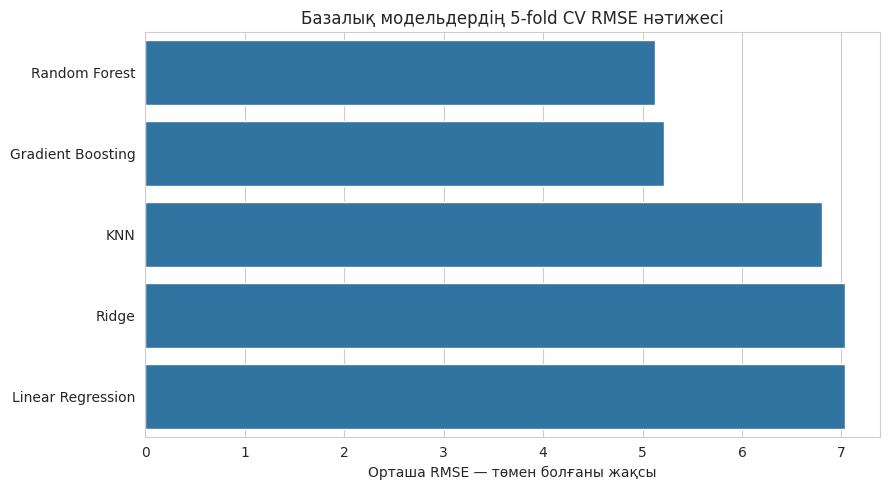

In [13]:
# TODO 6.1: модельдерді салыстыру

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

models = {
    'Linear Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),

    'Ridge': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0))
    ]),

    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsRegressor(n_neighbors=7))
    ]),

    'Random Forest': RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=1
    ),

    'Gradient Boosting': GradientBoostingRegressor(
        random_state=RANDOM_STATE
    )
}

cv_rows = []

for name, model in models.items():
    rmse_scores = -cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )

    r2_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='r2',
        n_jobs=-1
    )

    cv_rows.append({
        'model': name,
        'mean_RMSE': rmse_scores.mean(),
        'std_RMSE': rmse_scores.std(),
        'mean_R2': r2_scores.mean(),
        'std_R2': r2_scores.std()
    })

cv_results = (
    pd.DataFrame(cv_rows)
    .sort_values('mean_RMSE')
    .reset_index(drop=True)
)

display(cv_results.round(4))

plt.figure(figsize=(9, 5))
sns.barplot(
    data=cv_results,
    x='mean_RMSE',
    y='model'
)
plt.title("Базалық модельдердің 5-fold CV RMSE нәтижесі")
plt.xlabel("Орташа RMSE — төмен болғаны жақсы")
plt.ylabel("")
plt.tight_layout()
plt.show()

**Таңдалған модельдер:** 7-бөлімде **Random Forest** және **Gradient Boosting** бапталады. Олар компоненттер мен беріктік арасындағы өзара әрекеттесулерді және `age` әсерінің сызықты еместігін модельдейді. Ансамбльдердің сызықты модельдерден ұтуы деректің табиғаты сызықты емес екенін көрсетеді.

## 7. Гиперпараметрлерді баптау

Таңдалған екі модель үшін `GridSearchCV` қолданыңыз. Тор кеңдігін ақылға қонымды деңгейде ұстаңыз: әр модельдің 2-3 негізгі параметрі, әрқайсысына 3-5 мән. Скорды бір метрикада қалдырыңыз (мысалы, RMSE) — метрикаларды араластыру қорытындыны түсініксіз етеді.

### Тапсырма 7.1: бірінші модельді баптау

In [14]:
# TODO 7.1: GridSearchCV бірінші модель үшін
rf = RandomForestRegressor(
    random_state=RANDOM_STATE,
    n_jobs=1
)

rf_param_grid = {
    'n_estimators': [200, 400, 600],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 2, 4]
}

rf_search = GridSearchCV(
    estimator=rf,
    param_grid=rf_param_grid,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_
rf_cv_rmse = -rf_search.best_score_

print("Random Forest үздік параметрлері:")
print(rf_search.best_params_)
print(f"Random Forest үздік CV RMSE: {rf_cv_rmse:.4f}")


Random Forest үздік параметрлері:
{'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 400}
Random Forest үздік CV RMSE: 5.1260


### Тапсырма 7.2: екінші модельді баптау

In [15]:
# TODO 7.2: GridSearchCV екінші модель үшін
gb = GradientBoostingRegressor(
    random_state=RANDOM_STATE
)

gb_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.03, 0.05, 0.10],
    'max_depth': [2, 3, 4]
}

gb_search = GridSearchCV(
    estimator=gb,
    param_grid=gb_param_grid,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

gb_search.fit(X_train, y_train)

best_gb = gb_search.best_estimator_
gb_cv_rmse = -gb_search.best_score_

print("Gradient Boosting үздік параметрлері:")
print(gb_search.best_params_)
print(f"Gradient Boosting үздік CV RMSE: {gb_cv_rmse:.4f}")

tuned_results = pd.DataFrame({
    'model': ['Random Forest', 'Gradient Boosting'],
    'best_CV_RMSE': [rf_cv_rmse, gb_cv_rmse]
}).sort_values('best_CV_RMSE')

display(tuned_results.round(4))


Gradient Boosting үздік параметрлері:
{'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 300}
Gradient Boosting үздік CV RMSE: 4.6571


,model,best_CV_RMSE
1,Gradient Boosting,4.6571
0,Random Forest,5.1260


## 8. Соңғы модельді бағалау

Ең жақсы кросс-валидация нәтижесін көрсеткен модельді тест жиынтығында бір рет қана бағалаңыз.

### Тапсырма 8.1

Соңғы модель үшін MAE, RMSE, R² метрикаларын есептеңіз. Әрқайсысының мағынасын өз сөзіңізбен түсіндіріңіз: неге бір модель RMSE-де ұтады, ал басқасы MAE-де ұтуы мүмкін? Тестте болжанған және шын мәндерді scatter plot-та көрсетіңіз (диагональ сызықты қосыңыз).

Соңғы модель: Gradient Boosting
Test MAE : 2.7638 MPa
Test RMSE: 4.2665 MPa
Test R²  : 0.9294


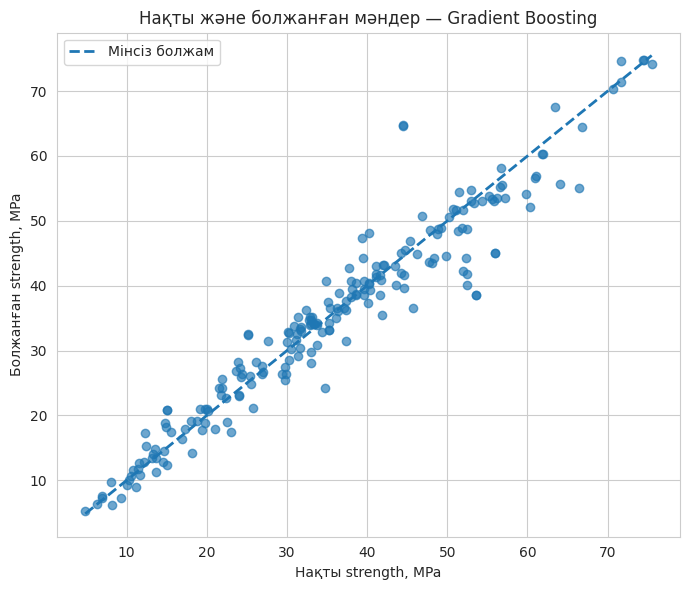

In [16]:
# TODO 8.1: соңғы бағалау мен график
if gb_cv_rmse <= rf_cv_rmse:
    final_model_name = 'Gradient Boosting'
    final_model = best_gb
else:
    final_model_name = 'Random Forest'
    final_model = best_rf

y_pred = final_model.predict(X_test)

test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)

print("Соңғы модель:", final_model_name)
print(f"Test MAE : {test_mae:.4f} MPa")
print(f"Test RMSE: {test_rmse:.4f} MPa")
print(f"Test R²  : {test_r2:.4f}")

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.65)

lower = min(y_test.min(), y_pred.min())
upper = max(y_test.max(), y_pred.max())

plt.plot(
    [lower, upper],
    [lower, upper],
    linestyle='--',
    linewidth=2,
    label='Мінсіз болжам'
)

plt.xlabel("Нақты strength, MPa")
plt.ylabel("Болжанған strength, MPa")
plt.title(f"Нақты және болжанған мәндер — {final_model_name}")
plt.legend()
plt.tight_layout()
plt.show()


**Метрикалардың мағынасы:** MAE — болжамның орташа абсолюттік қатесі және оны MPa түрінде тікелей түсіндіруге болады. RMSE үлкен қателерді күштірек жазалайды. R² мақсаттық белгідегі вариацияның қандай үлесін модель түсіндіретінін көрсетеді. Бір модель көп жағдайда аз қателесіп MAE-де ұтуы мүмкін, бірақ сирек үлкен қателері болса RMSE-де жеңіледі.

### Тапсырма 8.2: қалдықтарды талдау

Residual plot салыңыз (болжанған мәнге қарсы қалдық). Қалдықтарда жүйелі үлгі бар ма? Мысалы, модель жоғары беріктікте (60 MPa жоғары) төмен болжай ма? Егер жүйелі үлгі болса, бұл модельдің әлсіз тұсы туралы нені білдіреді және оны қалай жақсартуға болады?

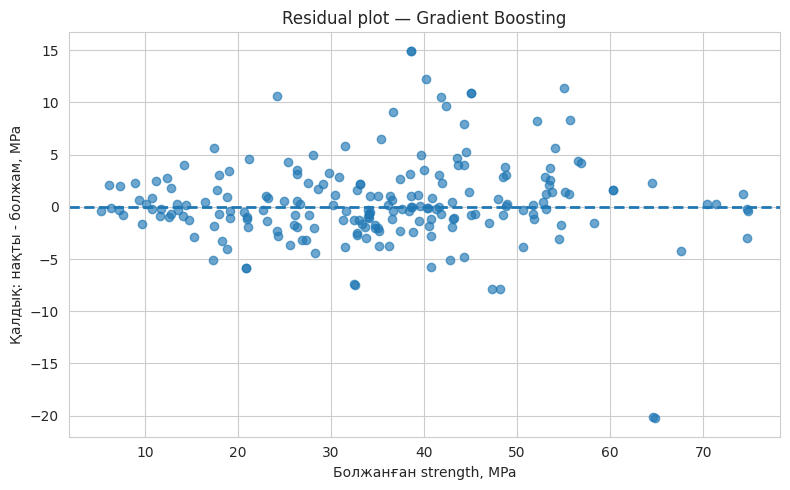

60 MPa және одан жоғары үлгілер: 15
Орташа қалдық (оң болса модель төмен болжайды): 2.401
Олардағы MAE: 3.451 MPa


In [17]:
# TODO 8.2: residual plot

residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.65)
plt.axhline(0, linestyle='--', linewidth=2)

plt.xlabel("Болжанған strength, MPa")
plt.ylabel("Қалдық: нақты - болжам, MPa")
plt.title(f"Residual plot — {final_model_name}")
plt.tight_layout()
plt.show()

high_strength_mask = y_test >= 60

if high_strength_mask.sum() > 0:
    high_residual_mean = residuals[high_strength_mask].mean()
    high_mae = mean_absolute_error(
        y_test[high_strength_mask],
        y_pred[high_strength_mask]
    )

    print("60 MPa және одан жоғары үлгілер:", high_strength_mask.sum())
    print(
        "Орташа қалдық "
        f"(оң болса модель төмен болжайды): {high_residual_mean:.3f}"
    )
    print(f"Олардағы MAE: {high_mae:.3f} MPa")

**Талдау:** жақсы модельде қалдықтар нөл сызығының айналасында кездейсоқ орналасуы керек. Қисық, «желпуіш» немесе белгілі диапазонда бір бағытқа ығысқан үлгі жүйелі bias бар екенін көрсетеді. 60 MPa-дан жоғары бетондарда қалдықтар көбіне оң болса, модель жоғары беріктікті төмен болжайды; мұны жоғары беріктіктегі деректерді көбейту немесе қуаттырақ boosting моделін қолдану арқылы жақсартуға болады.

### Тапсырма 8.3: белгілердің маңыздылығы

Ағаш моделі үшін `feature_importances_`, сызықты модель үшін коэффициенттердің абсолюттік мәндерін қолданыңыз. Ең маңызды үш белгіні атаңыз және олардың EDA-да көрсеткен корреляциясымен сәйкес келе ме — салыстырыңыз. Бетон технологиясы бойынша күтілетін маңызды белгілер (цемент мөлшері, су-цемент қатынасы, қатаю мерзімі) сіздің моделіңіздің басты белгілерімен сәйкес келе ме?

,feature,importance
0,binder_total,0.3299
1,log_age,0.1930
2,age,0.1758
3,water_cement_ratio,0.1217
4,water,0.0544
5,cement,0.0327
6,slag,0.0283
7,fly_ash,0.0164
8,superplasticizer,0.0142
9,fine_agg,0.0127


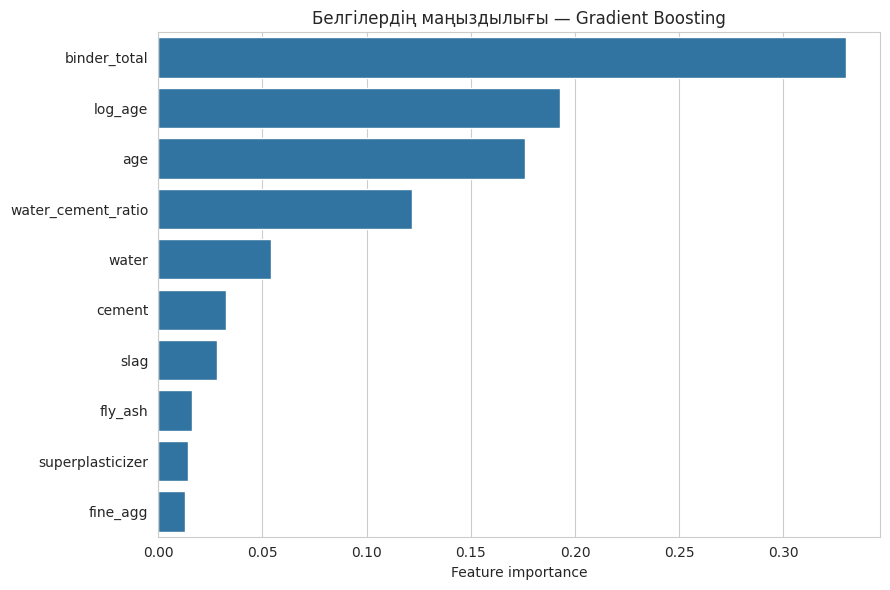

Ең маңызды үш белгі: ['binder_total', 'log_age', 'age']


,feature_importance,strength_correlation
binder_total,0.3299,0.6132
log_age,0.1930,0.5495
age,0.1758,0.3289


In [18]:
# TODO 8.3: белгілердің маңыздылығы
importance = pd.Series(
    final_model.feature_importances_,
    index=X_train.columns,
    name='importance'
).sort_values(ascending=False)

importance_df = importance.reset_index()
importance_df.columns = ['feature', 'importance']

display(importance_df.head(10).round(4))

plt.figure(figsize=(9, 6))
sns.barplot(
    data=importance_df.head(10),
    x='importance',
    y='feature'
)
plt.title(f"Белгілердің маңыздылығы — {final_model_name}")
plt.xlabel("Feature importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

top3_features = importance.head(3).index.tolist()
print("Ең маңызды үш белгі:", top3_features)

correlations = (
    df_model.corr(numeric_only=True)['strength']
    .drop('strength')
    .sort_values(key=np.abs, ascending=False)
)

comparison = pd.DataFrame({
    'feature_importance': importance,
    'strength_correlation': correlations
}).dropna()

display(comparison.loc[top3_features].round(4))


**Салыстыру:** feature importance пен қарапайым корреляция бір ұғым емес. Корреляция жеке белгінің сызықты байланысын өлшейді, ал ағаш ансамблі шектерді, өзара әрекеттесуді және сызықты емес әсерді есепке алады. Инженерлік тұрғыдан `water_cement_ratio`, `cement` немесе `binder_total`, сондай-ақ `age` немесе `log_age` маңызды болуы күтіледі.

## 9. Қорытынды және талқылау

Төмендегі сұрақтарға қысқа жауап беріңіз (әрқайсысы 2-4 сөйлем).

### 9.1. Ең жақсы модель қайсысы болды және неге дәл ол ұтты?

Код Random Forest пен Gradient Boosting ішінен CV RMSE көрсеткіші ең төмен модельді автоматты түрде соңғы модель ретінде таңдайды. Әдетте Gradient Boosting жақсы нәтиже береді, себебі ол әлсіз ағаштарды кезең-кезеңімен қосып, алдыңғы модельдердің қалдық қателерін түзетеді. Ансамбльдің жеңуі бетон құрамының әсері сызықты емес және компоненттер арасында өзара әрекеттесу бар екенін көрсетеді.

### 9.2. ±5 MPa қателік құрылыс үшін жеткілікті ме?

±5 MPa кейбір алдын ала қоспа жобалау немесе скрининг есептері үшін пайдалы болуы мүмкін, бірақ қауіпсіздікке тікелей әсер ететін соңғы инженерлік шешім үшін модель жалғыз дәлел болмауы керек. Қабылданатын қателік жобалық беріктікке, қауіпсіздік коэффициентіне және қолданылатын стандартқа байланысты. Модель зертханалық сынақты толық алмастырмай, шешім қолдау құралы ретінде қолданылуы тиіс.

### 9.3. Артық және төмен бағалаудың тәуекелдері қандай?

Беріктікті артық бағалау ең қауіпті: нақты бетон жобалық талапты орындамаса да, модель оны қауіпсіз деп көрсетуі мүмкін. Төмен бағалау консервативті болғанымен, артық цемент жұмсауға, қайта сынауға немесе жарамды қоспаны негізсіз қабылдамауға әкеледі. Сондықтан қауіпсіздік маңызды контексте артық болжауды күштірек жазалайтын асимметриялық loss немесе төменгі сенімділік шегі қолданылуы мүмкін.

### 9.4. Қосымша бір апта болса, нені жақсартуға болады?

Алдымен nested cross-validation немесе бөлек validation жиынтығымен гиперпараметр таңдаудың тұрақтылығын тексерер едім. Одан кейін XGBoost, LightGBM немесе CatBoost, uncertainty estimation және SHAP түсіндірмелерін қосып, жоғары беріктіктегі сирек үлгілерді жеке талдар едім. Температура, қатаю режимі және материалдардың химиялық құрамы сияқты қосымша белгілер де модель сапасын арттыруы мүмкін.

*Жауаптарыңызды осы ұяшыққа жазыңыз.*

## Тапсыру талаптары

Дәптеріңізді толық орындалған күйде сақтаңыз (барлық ұяшықтардың шығысы көрінуі керек). Файл атауы: `final_lab_regression_ATЫ_ЖӨНІ.ipynb`. Тапсырма көшірілген жағдайда автоматты тексеру арқылы анықталады.